Exploratory Data Analysis Using Variance 

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy import stats
df=pd.read_csv("customer_dataset.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
print(df.shape)
print(df.dtypes)


(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [7]:
#The Total charges is a string variable.Now we have to convert it into numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df[["tenure", "MonthlyCharges", "TotalCharges"]].dtypes

tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object

Checking the missing values


In [8]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].isnull().sum()

tenure             0
MonthlyCharges     0
TotalCharges      11
dtype: int64

Using Discriptive Statistics


In [9]:
numerical_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


Calculating the Variance

In [10]:
variance = df[numerical_cols].var()
print(variance)

tenure            6.031681e+02
MonthlyCharges    9.054109e+02
TotalCharges      5.138252e+06
dtype: float64


In [11]:
std =df [numerical_cols].std()
std

tenure              24.559481
MonthlyCharges      30.090047
TotalCharges      2266.771362
dtype: float64

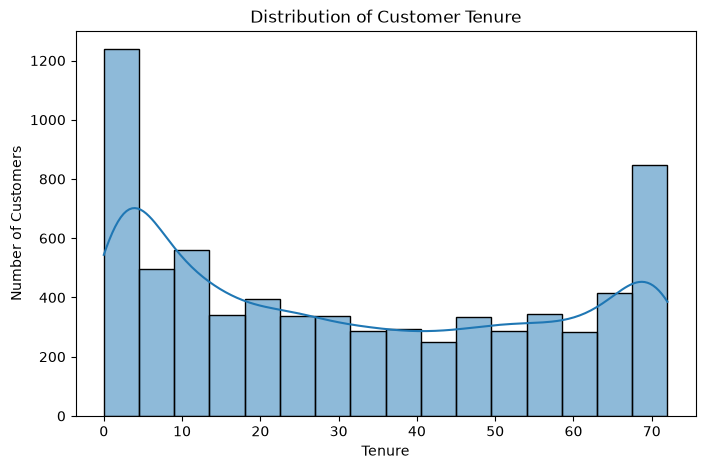

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")

plt.show()

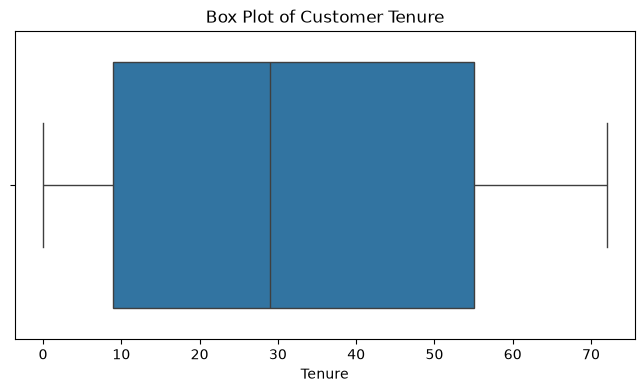

In [13]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="tenure"
)

plt.title("Box Plot of Customer Tenure")
plt.xlabel("Tenure")

plt.show()

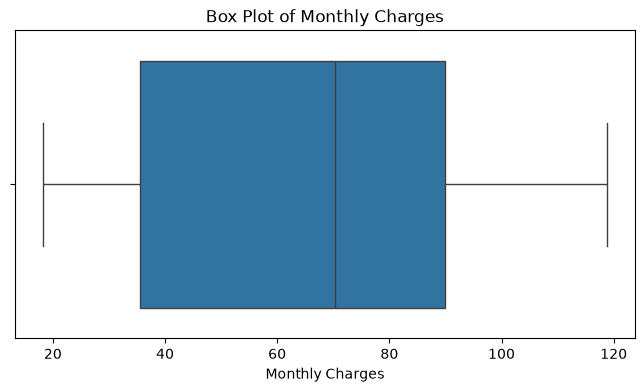

In [14]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="MonthlyCharges"
)

plt.title("Box Plot of Monthly Charges")
plt.xlabel("Monthly Charges")

plt.show()

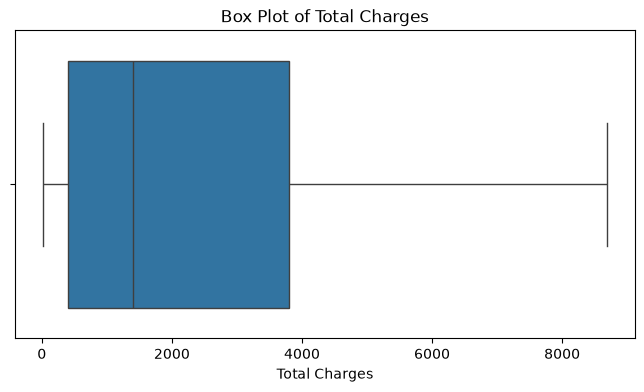

In [15]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="TotalCharges"
)

plt.title("Box Plot of Total Charges")
plt.xlabel("Total Charges")

plt.show()

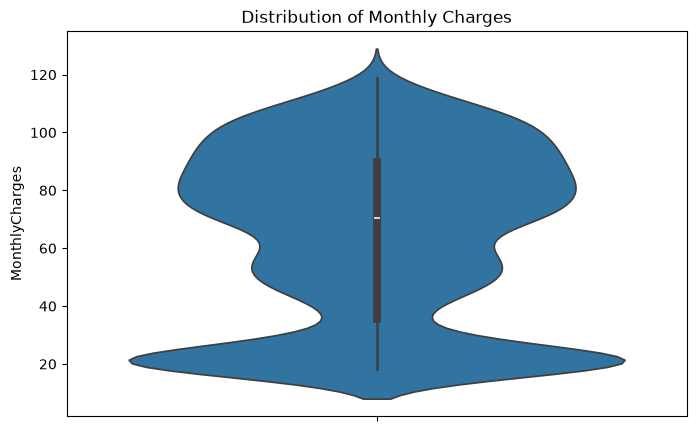

In [16]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    y="MonthlyCharges"
)

plt.title("Distribution of Monthly Charges")

plt.show()

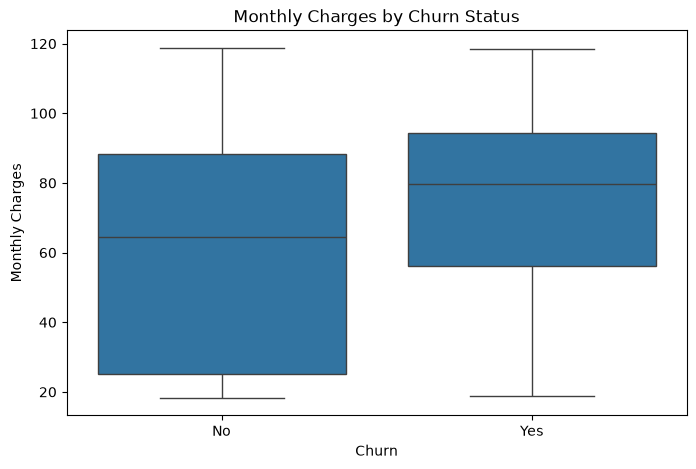

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

Group-wise Variance

In [18]:
churn_variance = df.groupby("Churn")["MonthlyCharges"].var()

print(churn_variance)

Churn
No     966.752767
Yes    608.414183
Name: MonthlyCharges, dtype: float64


Group-wise Standard Deviation

In [19]:
churn_std = df.groupby("Churn")["MonthlyCharges"].std()

print(churn_std)

Churn
No     31.092648
Yes    24.666053
Name: MonthlyCharges, dtype: float64


Statistical Tests

In [22]:
from scipy import stats

churn_yes = df.loc[
    df["Churn"] == "Yes",
    "MonthlyCharges"
].dropna()

churn_no = df.loc[
    df["Churn"] == "No",
    "MonthlyCharges"
].dropna()

statistic, p_value = stats.levene(
    churn_yes,
    churn_no
)

print("Levene Statistic:", statistic)
print("P-value:", p_value)
if p_value < 0.05:
    print("Evidence suggests that the group variances are different.")
else:
    print("There is not sufficient evidence to conclude that the group variances are different.")

Levene Statistic: 361.8444859598828
P-value: 1.0261244899399376e-78
Evidence suggests that the group variances are different.


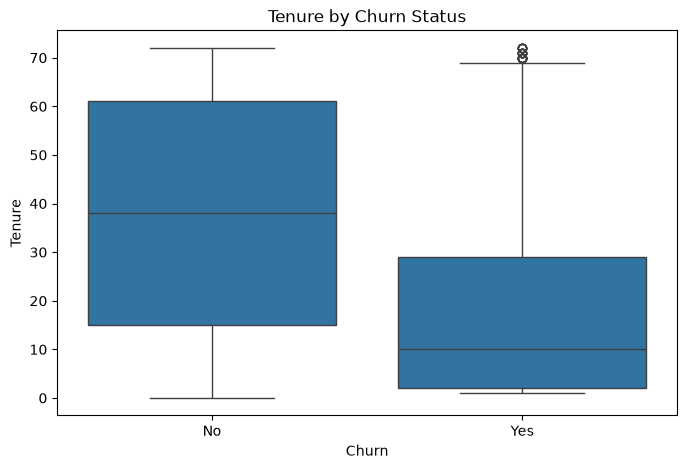

Churn
No     581.474226
Yes    381.464768
Name: tenure, dtype: float64

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.show()

df.groupby("Churn")["tenure"].var()

In [24]:
tenure_yes = df.loc[
    df["Churn"] == "Yes",
    "tenure"
].dropna()

tenure_no = df.loc[
    df["Churn"] == "No",
    "tenure"
].dropna()

statistic, p_value = stats.levene(
    tenure_yes,
    tenure_no
)

print("Levene Statistic:", statistic)
print("P-value:", p_value)

Levene Statistic: 417.1696228201477
P-value: 3.963539602777956e-90


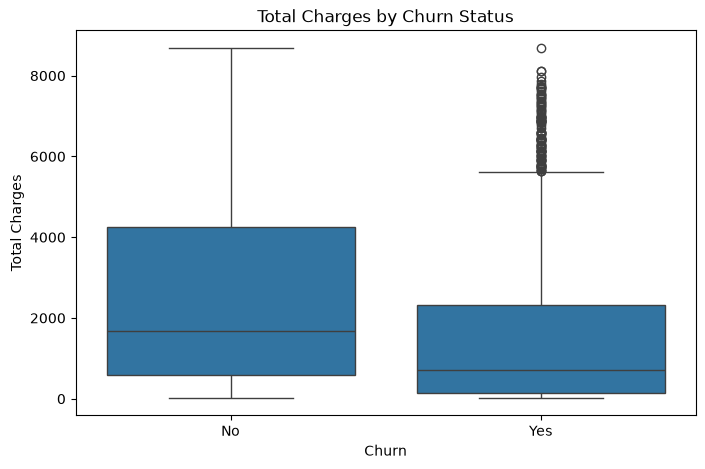

Levene Statistic: 166.5404379147951
P-value: 1.126148435225079e-37


In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

df.groupby("Churn")["TotalCharges"].var()

total_yes = df.loc[
    df["Churn"] == "Yes",
    "TotalCharges"
].dropna()

total_no = df.loc[
    df["Churn"] == "No",
    "TotalCharges"
].dropna()

statistic, p_value = stats.levene(
    total_yes,
    total_no
)

print("Levene Statistic:", statistic)
print("P-value:", p_value)